# **00 - Análisis Exploratorio de Datos y Justificación de Variables**

En este cuaderno vamos a explorar el dataset original para extraer conclusiones que guiarán nuestra fase de Ingeniería de Características. 

## 1. **El problema de utilizar el "Nombre del Equipo" como variable predictora**

Una tentación habitual al predecir partidos de fútbol es pasarle al modelo predictivo el nombre de los equipos. Sin embargo, esto es una mala práctica conocida como "fuga de datos por no estacionariedad". 

El rendimiento de un club no es estático, varía enormemente con los años debido a cambios de entrenador, presupuesto o plantilla. Si un modelo aprende que "Sevilla = Equipo Ganador" basándose en datos de 2015, fracasará estrepitosamente al intentar predecir sus resultados en 2023, donde peleó por evitar el descenso.

Vamos a demostrar esta volatilidad visualmente analizando la evolución del Sevilla FC a lo largo de las temporadas.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/raw/train.csv') 

df.head(3)

,id,division,anio_fin_temporada,fecha,local,visitante,goles_local,goles_visitante,resultado
0,10341_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Espanol,Almeria,3,3,X_empate
1,10334_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Osasuna,Girona,2,1,1_local
2,10335_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Real Madrid,Ath Bilbao,1,1,X_empate


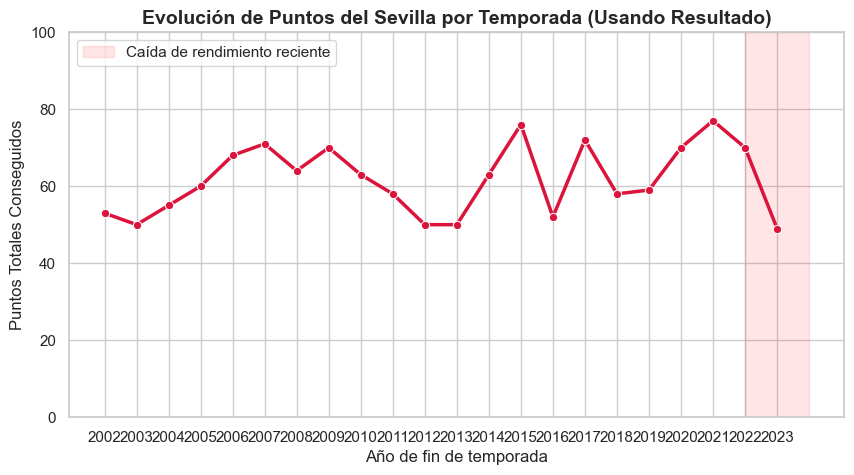

In [6]:
equipo_analisis = 'Sevilla'

df_equipo = df[(df['local'] == equipo_analisis) | (df['visitante'] == equipo_analisis)].copy()
 
def calcular_puntos_por_resultado(row, equipo):
    res = str(row['resultado']).upper() 
    
    if row['local'] == equipo:
        if res == '1_LOCAL': return 3
        elif res == 'X_EMPATE': return 1
        else: return 0
    else: 
        if res == '2_VISITANTE': return 3
        elif res == 'X_EMPATE': return 1
        else: return 0


df_equipo['puntos_conseguidos'] = df_equipo.apply(lambda x: calcular_puntos_por_resultado(x, equipo_analisis), axis=1)

puntos_por_temporada = df_equipo.groupby('anio_fin_temporada')['puntos_conseguidos'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=puntos_por_temporada, x='anio_fin_temporada', y='puntos_conseguidos', 
             marker='o', linewidth=2.5, color='crimson')

plt.title(f'Evolución de Puntos del {equipo_analisis} por Temporada (Usando Resultado)', fontsize=14, fontweight='bold')
plt.xlabel('Año de fin de temporada', fontsize=12)
plt.ylabel('Puntos Totales Conseguidos', fontsize=12)
plt.xticks(puntos_por_temporada['anio_fin_temporada'])
plt.ylim(0, 100)

plt.axvspan(2022, 2024, color='red', alpha=0.1, label='Caída de rendimiento reciente')
plt.legend()
plt.show()

## 2. **Rendimiento en casa y como visitante**

Aislar el rendimiento general de un equipo no es suficiente. En el fútbol hay equipos que son muy fuertes cuando juegan en su estadio pero débiles a domicilio, equipos más equilibrados y equipos que tienen mejores resultados jugando fuera de casa. También veremos que el esto puede variar según la temporada, por ejemplo el Osasuna es conocido por ser un equipo que saca muchos puntos jugando de local, pero en la temporada 2021/2022 fue al revés como podremos ver en el siguiente gráfico.

Para que nuestro modelo predictivo sea preciso, no podemos pasarle únicamente los puntos acumulados en general, sino que debemos contextualizar dónde se juega el partido. Vamos a demostrar visualmente esta disparidad comparando el porcentaje de victorias como local frente al porcentaje de victorias como visitante para varios equipos en una misma temporada. Esto justificará la creación posterior de variables específicas como el promedio de puntos del local en su estadio y el promedio de puntos del visitante a domicilio.

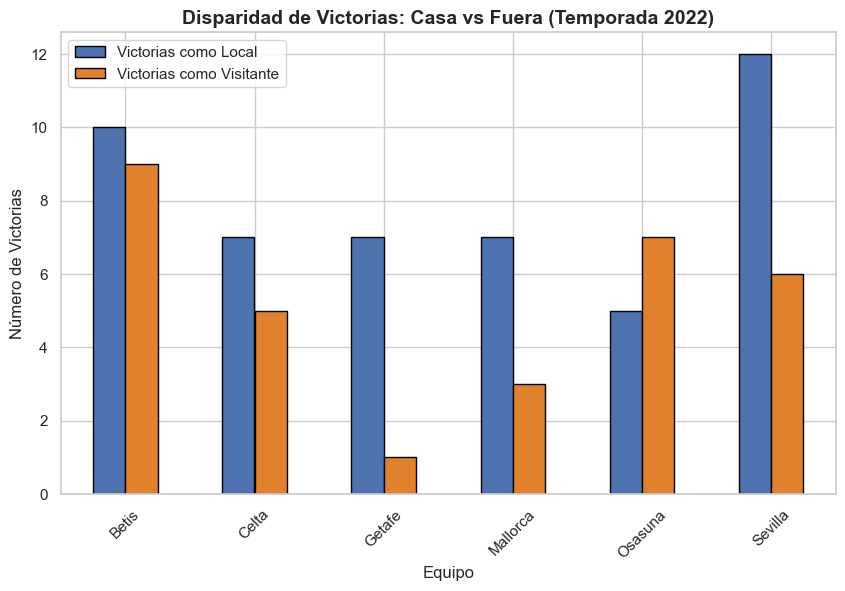

In [ ]:
df_temp = df[df['anio_fin_temporada'] == 2022].copy()


victorias_casa = df_temp[df_temp['resultado'] == '1_local'].groupby('local').size().reset_index(name='v_casa')

victorias_fuera = df_temp[df_temp['resultado'] == '2_visitante'].groupby('visitante').size().reset_index(name='v_fuera')


df_comparativa = pd.merge(victorias_casa, victorias_fuera, left_on='local', right_on='visitante', how='outer').fillna(0)
df_comparativa = df_comparativa.rename(columns={'local': 'equipo'})


equipos_muestra = ['Sevilla', 'Osasuna', 'Celta', 'Mallorca', 'Betis', 'Getafe']
df_muestra = df_comparativa[df_comparativa['equipo'].isin(equipos_muestra)].set_index('equipo')

ax = df_muestra[['v_casa', 'v_fuera']].plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#E1812C'], edgecolor='black')

plt.title('Disparidad de Victorias: Casa vs Fuera (Temporada 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Equipo', fontsize=12)
plt.ylabel('Número de Victorias', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Victorias como Local', 'Victorias como Visitante'])

plt.show()

## 3. **Rendimiento Acumulado**

Al descartar el "Nombre del Equipo" como variable predictora, necesitamos una métrica que resuma el nivel real del equipo en la temporada actual. 

La variable más lógica es la cantidad de puntos acumulados antes de disputarse el encuentro. Sin embargo, en el fútbol moderno, los empates a puntos son muy comunes. Para desempatar el nivel real de dos equipos con los mismos puntos, la siguiente estadística más reveladora es la Diferencia de Goles. Los equipos con una diferencia de goles positiva tienden a ser dominadores de los partidos, incluso si han tenido mala suerte en algún resultado puntual.

C:\Users\1900d\AppData\Local\Temp\ipykernel_21324\2716382843.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_y_bottom.index, y=top_y_bottom['Diferencia'], palette="coolwarm_r")


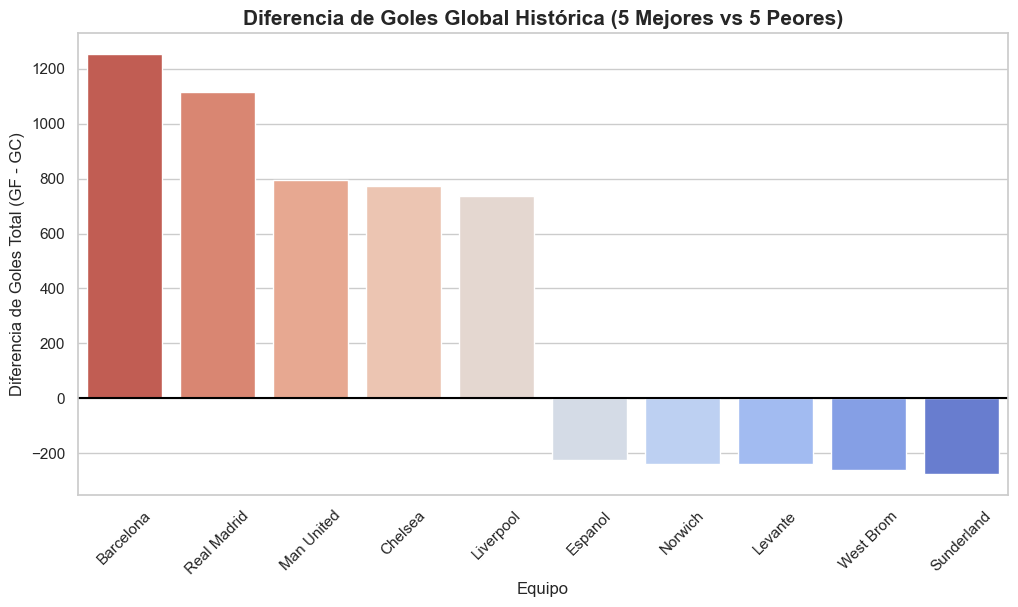

In [4]:
gf_local = df.groupby('local')['goles_local'].sum()
gf_visitante = df.groupby('visitante')['goles_visitante'].sum()
total_gf = gf_local.add(gf_visitante)

gc_local = df.groupby('local')['goles_visitante'].sum()
gc_visitante = df.groupby('visitante')['goles_local'].sum()
total_gc = gc_local.add(gc_visitante)

df_goles = pd.DataFrame({'GF': total_gf, 'GC': total_gc})
df_goles['Diferencia'] = df_goles['GF'] - df_goles['GC']

df_goles = df_goles.sort_values('Diferencia', ascending=False)
top_y_bottom = pd.concat([df_goles.head(5), df_goles.tail(5)])

plt.figure(figsize=(12, 6))
sns.barplot(x=top_y_bottom.index, y=top_y_bottom['Diferencia'], palette="coolwarm_r")

plt.title('Diferencia de Goles Global Histórica (5 Mejores vs 5 Peores)', fontsize=15, fontweight='bold')
plt.xlabel('Equipo', fontsize=12)
plt.ylabel('Diferencia de Goles Total (GF - GC)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1.5)

plt.show()

## 4. **Estado de forma o rachas a corto plazo**

Los puntos acumulados en la temporada nos dan una idea general del equipo, pero el fútbol es un deporte de dinámicas emocionales y físicas. Un equipo puede ir tercero en la liga por un gran inicio de temporada, pero llegar al partido actual con 4 lesionados y encadenando varias derrotas.

Para capturar el estado de forma de los equipos, es imprescindible generar variables de ventana temporal corta, como los puntos conseguidos y el promedio de goles anotados/encajados en sus últimos 3 y 5 partidos. Esto permitirá al algoritmo distinguir entre un equipo que llega con mala dinámica y un equipo en plena racha ganadora, independientemente de su posición general en la tabla.

## 5. **Conclusiones del Análisis Exploratorio**

A lo largo de este cuaderno hemos comprobado empíricamente que los datos crudos no son suficientes para entrenar un algoritmo de aprendizaje automático robusto. Los resultados históricos demuestran que:

1. **El nombre del equipo no es garantía de rendimiento futuro**.
2. **El factor campo altera significativamente la probabilidad de victoria**.
3. **El nivel real se mide por el acumulado global**.
4. **El fútbol es dinámico**.

**Siguientes pasos:**
Con estas conclusiones claras, justificamos la necesidad de crear un flujo de procesamiento de datos. En los **Cuadernos 01, 02 y 03**, transformaremos el conjunto de datos original aplicando técnicas de ingeniería de variables para calcular todas estas métricas de rendimiento, ventanas temporales y promedios, generando así el conjunto de datos definitivo con el que entrenaremos a nuestros algoritmos predictivos.